<Axes: xlabel='job_title_short,job_skills,excel,sql,python,r,aws,airflow'>

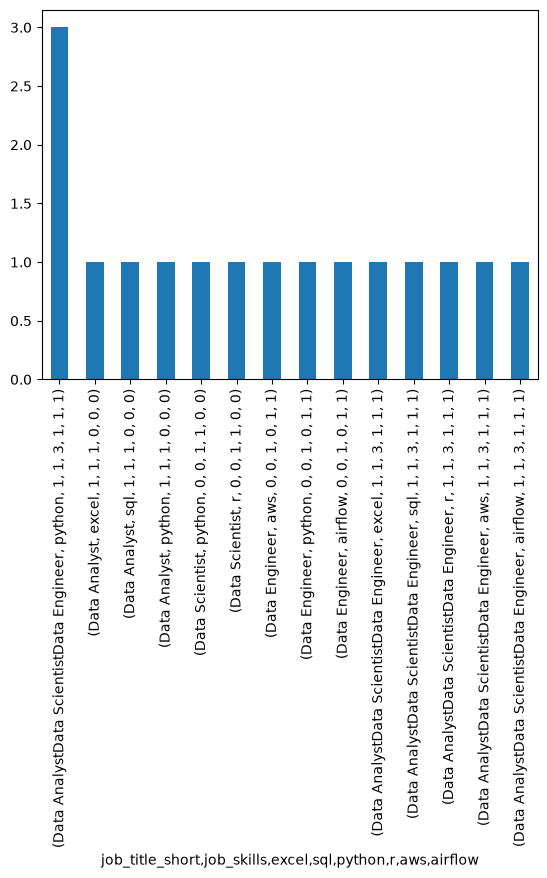

In [3]:
# Explode
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

data = {
    'job_title_short': ['Data Analyst', 'Data Scientist', 'Data Engineer'],
    'job_skills': [['excel', 'sql', 'python'], ['python', 'r'], ['aws', 'python', 'airflow']]
}

df_skills = pd.DataFrame(data)

df_skills
df_skill_lists = df_skills.copy()
for row in df_skill_lists.itertuples():
    for skill in row.job_skills:
        df_skill_lists[skill] = df_skill_lists['job_skills'].apply(lambda x: skill in x)
        df_skill_lists[skill] = df_skill_lists[skill].astype(int)
        
df_skill_lists.loc['Total'] = df_skill_lists.sum()



df_skill_lists.explode('job_skills')   # Explode out to where every value in its list is its individual row. Easier to run the value counts
df_skill_lists.explode('job_skills').value_counts().plot(kind = 'bar')

In [4]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


KeyboardInterrupt: 

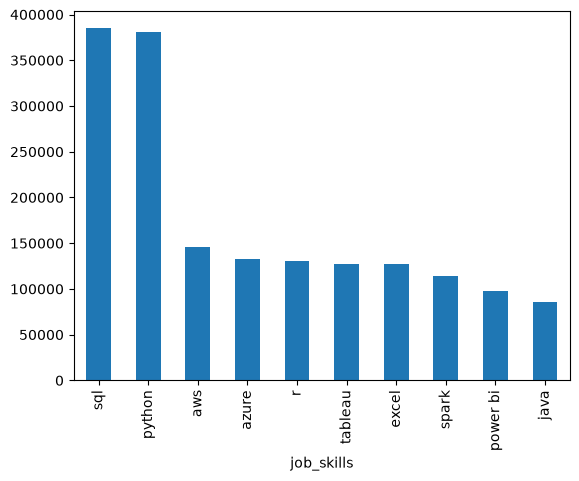

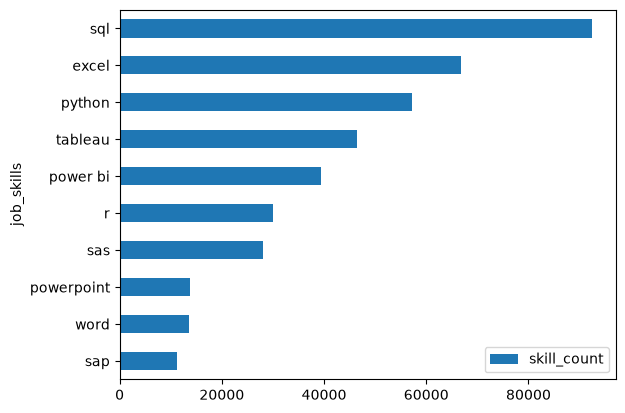

In [ ]:
df[['job_title_short','job_skills']].head(5) 

#Explode takes 2 paramebters, column and index. Transforms each element of a list-like into a row

df_exploded = df.explode('job_skills')      #broken out into individual rows for each skill
df_exploded['job_skills'].value_counts().head(10).plot(kind = 'bar') #visualize the skills

#Also want to group by their job title short and skills

skills_count = df_exploded.groupby(['job_title_short','job_skills']).size()
type(skills_count)       #This is a series. Lets convert it back to a dataframe
df_skills_count = skills_count.reset_index(name = 'skill_count')
df_skills_count = df_skills_count.sort_values(by = 'skill_count', ascending = False)
df_skills_count     

#Now we can plot
job_title = 'Data Analyst'
top_skills = 10

df_skill_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills)
df_skill_final

df_skill_final.plot(kind = 'barh', x = 'job_skills', y ='skill_count')

#Changes the axis. But we need the axis using GCA
plt.gca().invert_yaxis()


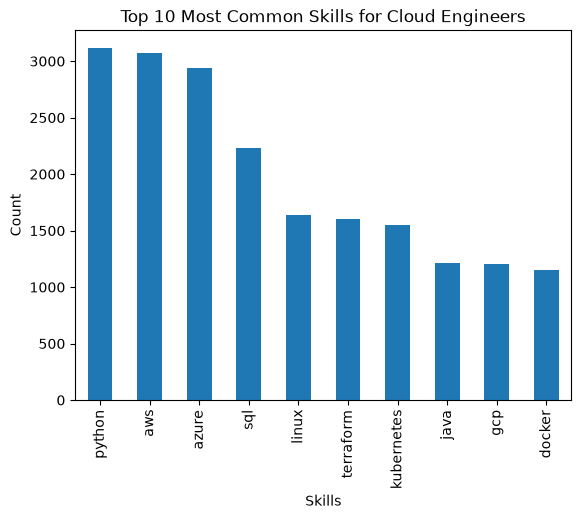

,job_title_short,num_unique_skills
0,Cloud Engineer,213


In [ ]:
# Practice PRoblems

df_CE = df[df['job_title_short'] == 'Cloud Engineer']
df_exploded = df_CE.explode('job_skills')
skill_counts = df_exploded['job_skills'].value_counts().head(10)
skill_counts.plot(kind='bar')
plt.xlabel('Skills')
plt.ylabel('Count')
plt.title('Top 10 Most Common Skills for Cloud Engineers')
plt.show()

df_exploded = df_CE.explode('job_skills')
skill_salary_avg = df_exploded.groupby('job_skills')['salary_year_avg'].mean().reset_index()
skill_salary_avg = skill_salary_avg.sort_values(by='salary_year_avg', ascending=False).head()

unique_skills_count = df_exploded.groupby('job_title_short')['job_skills'].nunique().reset_index()
unique_skills_count.columns = ['job_title_short', 'num_unique_skills']
unique_skills_count.head()


In [18]:
#Exercise: Trending Skills
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



In [6]:
df_DA = df[df['job_title_short'] =='Data Analyst'].copy()

<Axes: xlabel='job_posted_month_no'>

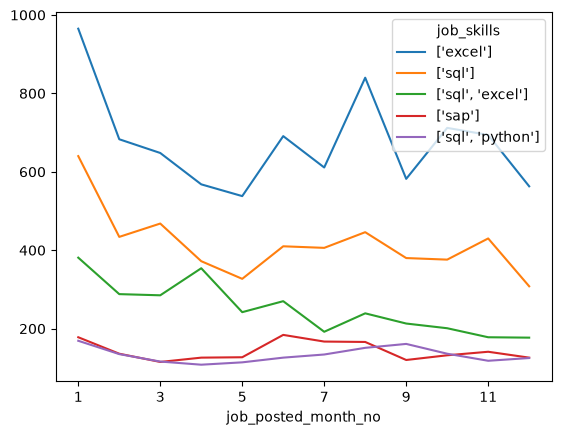

In [27]:
df_DA['job_posted_month_no']= df_DA['job_posted_date'].dt.month
df_DA_explode= df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending = False).index]

df_DA_pivot = df_DA_pivot.drop('Total')

df_DA_pivot.iloc[:, :5].plot(kind = 'line')